# 1.Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

# 2.Loading the Data 

In [5]:
base_path = r'/Users/mac/Desktop/sql_result'   # change to your actual path

presc_origin = pd.read_csv(base_path + '/prescription_by_origin.csv')
cost_per_script = pd.read_csv(base_path + '/cost_per_prescription.csv')
top_drugs_rev = pd.read_csv(base_path + '/top_20_drugs_by_revenue.csv')
revenue_per_drug = pd.read_csv(base_path + '/revenue_per_drug.csv')
drug_revenue = pd.read_csv(base_path + '/drug_revenue_std.csv')   # per‑drug revenue table

# 3.Data Cleaning (Cuurency and Numeric Conversion)

In [7]:
def clean_currency(col):
    return (
        col.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
        .astype(float)
    )

In [15]:
# After loading presc_origin
print("presc_origin columns:", presc_origin.columns.tolist())

presc_origin columns: ['Drug_Origin', 'total_prescriptions', 'total_revenue ', 'number_of_drugs']


In [16]:
# Strip whitespace from column names
presc_origin.columns = presc_origin.columns.str.strip()
cost_per_script.columns = cost_per_script.columns.str.strip()
top_drugs_rev.columns = top_drugs_rev.columns.str.strip()
revenue_per_drug.columns = revenue_per_drug.columns.str.strip()
drug_revenue.columns = drug_revenue.columns.str.strip()

In [17]:
print("After strip:", presc_origin.columns.tolist())

After strip: ['Drug_Origin', 'total_prescriptions', 'total_revenue', 'number_of_drugs']


In [18]:
def clean_currency(col):
    return (
        col.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
        .astype(float)
    )

# Prescriptions by origin
presc_origin['total_revenue'] = clean_currency(presc_origin['total_revenue'])
presc_origin['total_prescriptions'] = presc_origin['total_prescriptions'].astype(float)

# Cost per prescription
cost_per_script['total_revenue'] = clean_currency(cost_per_script['total_revenue'])
cost_per_script['total_prescriptions'] = cost_per_script['total_prescriptions'].astype(float)
cost_per_script['avg_cost_per_prescription'] = clean_currency(cost_per_script['avg_cost_per_prescription'])

# Top drugs
top_drugs_rev['revenue'] = clean_currency(top_drugs_rev['revenue'])
top_drugs_rev['prescriptions'] = top_drugs_rev['prescriptions'].astype(float)

# Revenue per drug (summary)
revenue_per_drug['total_revenue'] = clean_currency(revenue_per_drug['total_revenue'])
revenue_per_drug['avg_revenue_per_drug'] = clean_currency(revenue_per_drug['avg_revenue_per_drug'])

# Per‑drug revenue
drug_revenue['total_revenue'] = clean_currency(drug_revenue['total_revenue'])
drug_revenue['total_prescriptions'] = drug_revenue['total_prescriptions'].astype(float)

In [19]:
print(presc_origin.dtypes)

Drug_Origin             object
total_prescriptions    float64
total_revenue          float64
number_of_drugs          int64
dtype: object


# 4.Exploratory Data Analysis (EDA)

In [23]:
drug_revenue.columns = drug_revenue.columns.str.strip()

In [24]:
print("After strip:", drug_revenue.columns.tolist())

After strip: ['field8', 'drug_std', 'total_prescriptions', 'total_revenue']


In [28]:
print("Descriptive statistics of revenue per drug by origin:\n")
print(drug_revenue.groupby('field8')['total_revenue'].describe().applymap(lambda x: f"{x:,.2f}"))

Descriptive statistics of revenue per drug by origin:

                  count            mean             std        min  \
field8                                                               
Biotech          101.00  185,043,497.40  599,518,986.58  43,717.38   
Natural-derived  167.00   68,548,063.79  193,785,435.63     212.67   
Synthetic         61.00   86,412,022.81  164,811,381.18     597.24   

                          25%            50%             75%               max  
field8                                                                          
Biotech          1,738,760.70  11,349,142.52  101,263,256.51  4,884,226,408.42  
Natural-derived    434,223.54   5,055,447.32   48,650,868.89  1,550,673,258.57  
Synthetic        2,083,820.34  16,866,656.29   76,026,581.84    844,314,017.58  


# Box Plot-Revenue per Drug(with outliers)

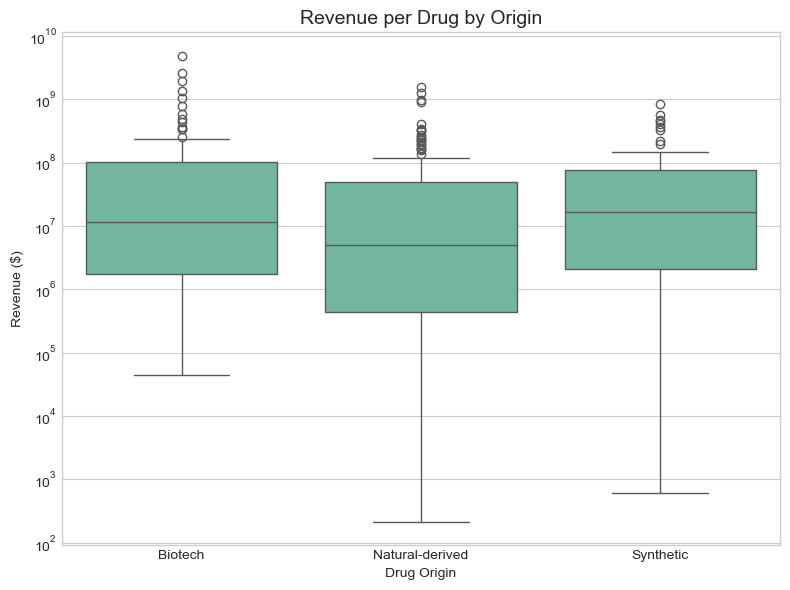

In [31]:
plt.figure(figsize=(8,6))
sns.boxplot(data=drug_revenue, x='field8', y='total_revenue')
plt.title('Revenue per Drug by Origin', fontsize=14)
plt.ylabel('Revenue ($)')
plt.xlabel('Drug Origin')
plt.yscale('log')   # log scale if values vary widely
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/Box_plot-revenue_per_rug.png', dpi=300)
plt.show()

# 4.4 Relationship Between Prescriptions and Revenue (Scatter plot)

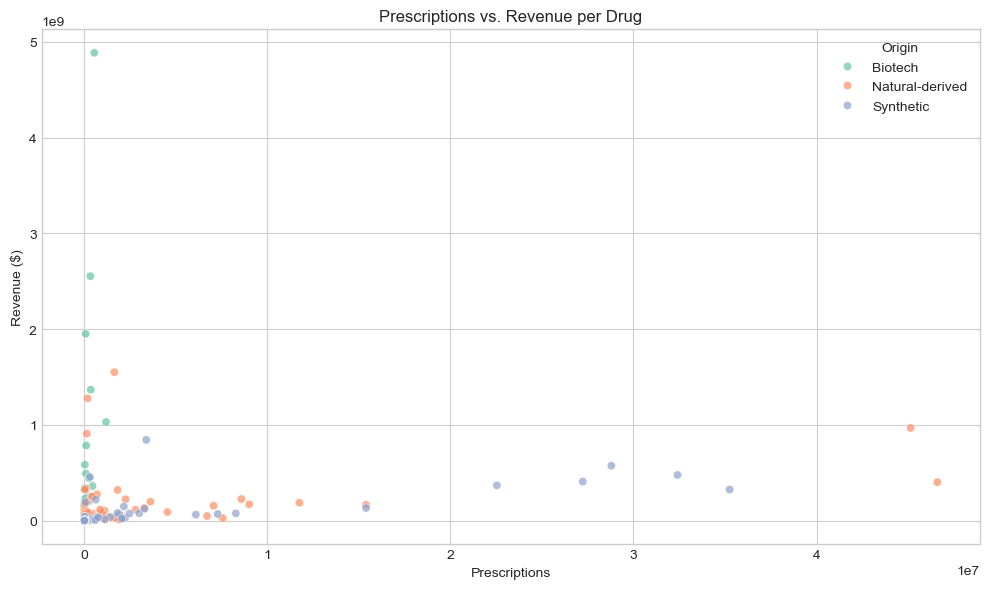

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=drug_revenue, x='total_prescriptions', y='total_revenue', hue='field8', alpha=0.7)
plt.title('Prescriptions vs. Revenue per Drug')
plt.xlabel('Prescriptions')
plt.ylabel('Revenue ($)')
plt.legend(title='Origin')
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/Relationship_btw_presc_and_revenue.png', dpi=300)
plt.show()

In [34]:
# Assistant
# Uncomment the line that calculates the correlation
corr = drug_revenue[['total_prescriptions', 'total_revenue']].corr()
print("Correlation between prescriptions and revenue:\n", corr)

Correlation between prescriptions and revenue:
                      total_prescriptions  total_revenue
total_prescriptions             1.000000       0.173403
total_revenue                   0.173403       1.000000


# 5 Visualizations for Key Findings

# 5.1 Total Prescriptions by Origin (Barchart)

In [39]:
presc_origin.columns = presc_origin.columns.str.strip()

In [40]:
print(presc_origin.columns.tolist())

['Drug_Origin', 'total_prescriptions', 'total_revenue', 'number_of_drugs']


In [41]:
sns.barplot(data=presc_origin, x='Drug_Origin', y='total_prescriptions')

<Axes: xlabel='Drug_Origin', ylabel='total_prescriptions'>

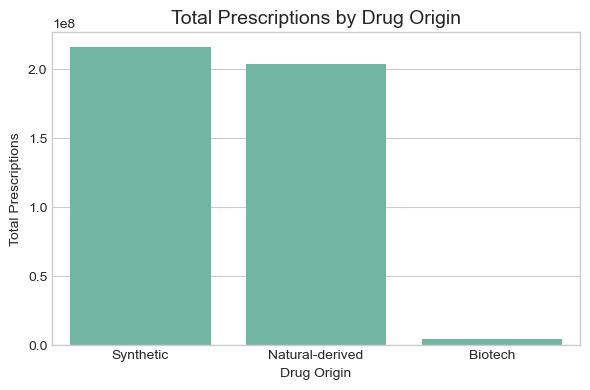

In [47]:
# Ensure column names are clean (do this once)
presc_origin.columns = presc_origin.columns.str.strip()

# Now plot
plt.figure(figsize=(6,4))
sns.barplot(data=presc_origin, x='Drug_Origin', y='total_prescriptions')
plt.title('Total Prescriptions by Drug Origin', fontsize=14)
plt.ylabel('Total Prescriptions')
plt.xlabel('Drug Origin')
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/tot_presc_by_origin_barchart.png', dpi=300)
plt.show()

# 5.2 Total Revenue by Origin (Bar Chart)

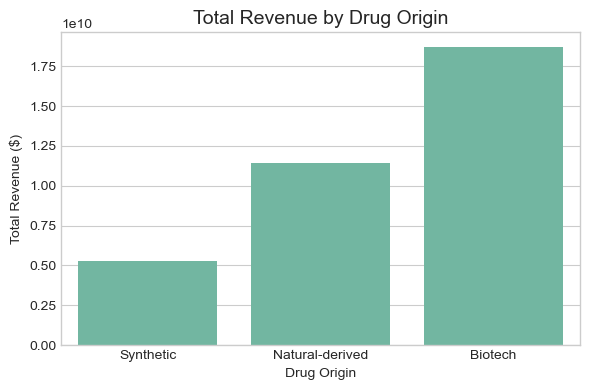

In [46]:
plt.figure(figsize=(6,4))
sns.barplot(data=presc_origin, x='Drug_Origin', y='total_revenue')
plt.title('Total Revenue by Drug Origin', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Drug Origin')
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/tot_revenue_by_origin_barchart.png', dpi=300)
plt.show()

# 5.3 Average Cost per Precription by Origin

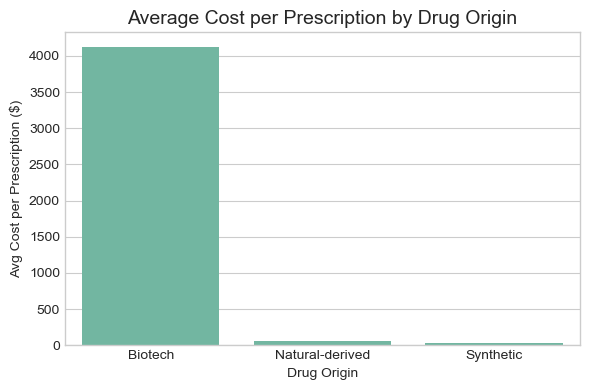

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(data=cost_per_script, x='Drug_Origin', y='avg_cost_per_prescription')
plt.title('Average Cost per Prescription by Drug Origin', fontsize=14)
plt.ylabel('Avg Cost per Prescription ($)')
plt.xlabel('Drug Origin')
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/Avr_cst_per_presc_barchart.png', dpi=300)
plt.show()

# 5.4 Top 10 Drugs by Revenue (Horizontal Bar Chart)

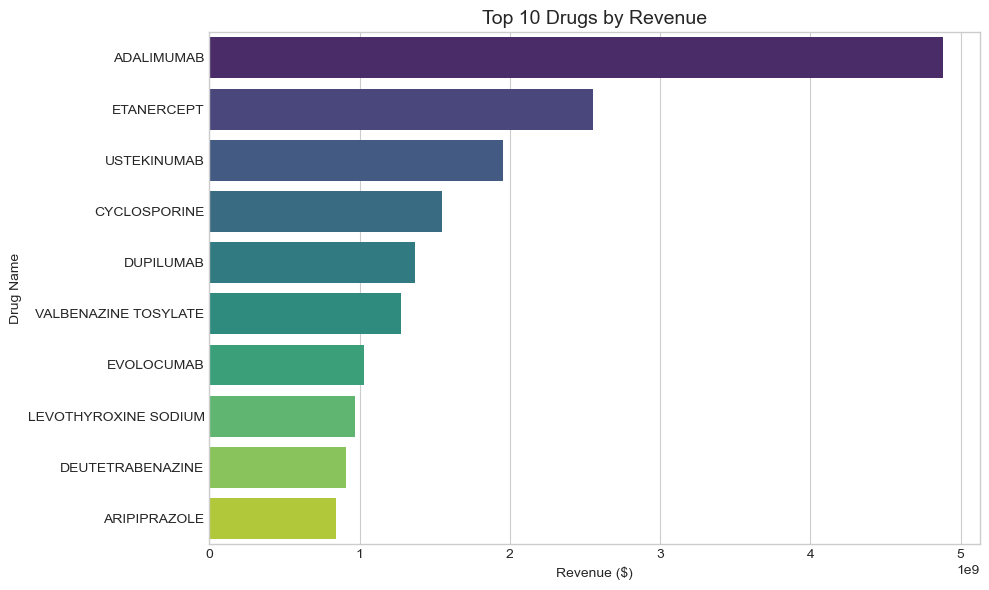

In [49]:
top10 = top_drugs_rev.sort_values('revenue', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10, y='drug_name', x='revenue', palette='viridis')
plt.title('Top 10 Drugs by Revenue', fontsize=14)
plt.xlabel('Revenue ($)')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.savefig('/Users/mac/Desktop/Top_10_Drugs_by_Revenue_barchart.png', dpi=300)
plt.show()

# 6. Statistical Testing 

In [51]:
nat_rev = drug_revenue[drug_revenue['field8'] == 'Natural-derived']['total_revenue']
syn_rev = drug_revenue[drug_revenue['field8'] == 'Synthetic']['total_revenue']

t_stat, p_value = stats.ttest_ind(nat_rev, syn_rev, equal_var=False)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: Significant difference in revenue between natural-derived and synthetic drugs.")
else:
    print("Fail to reject H0: No significant difference.")

t-statistic: -0.6901
p-value: 0.4914
Fail to reject H0: No significant difference.


In [52]:
from scipy.stats import f_oneway
groups = [group['total_revenue'].values for name, group in drug_revenue.groupby('field8')]
f_stat, p_anova = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_anova:.4f}")
if p_anova < 0.05:
    print("Significant difference among at least one pair of groups.")

ANOVA F-statistic: 3.3035, p-value: 0.0380
Significant difference among at least one pair of groups.


# 7. Summary Table for Report

In [53]:
summary = presc_origin.copy()
summary['total_prescriptions'] = summary['total_prescriptions'].apply(lambda x: f"{x:,.0f}")
summary['total_revenue'] = summary['total_revenue'].apply(lambda x: f"${x:,.2f}")
summary['number_of_drugs'] = summary['number_of_drugs'].apply(lambda x: f"{x:,.0f}")

print("\n=== Summary: Prescriptions and Revenue by Origin ===\n")
print(summary.to_string(index=False))


=== Summary: Prescriptions and Revenue by Origin ===

    Drug_Origin total_prescriptions      total_revenue number_of_drugs
      Synthetic         216,052,451  $5,271,133,391.69              61
Natural-derived         203,766,680 $11,447,526,653.20             167
        Biotech           4,537,190 $18,689,393,237.51             101
